In [3]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
!git clone https://github.com/liharikakk-lab/project.git


fatal: destination path 'project' already exists and is not an empty directory.


In [5]:
!ls /content

drive  project	sample_data


In [6]:
!cp "/content/drive/MyDrive/leesprojecipybnt_.ipynb" /content/project/

cp: cannot stat '/content/drive/MyDrive/leesprojecipybnt_.ipynb': No such file or directory


In [7]:
!ls /content/drive/MyDrive/

 240310597550_ApplicationForm.pdf
 Audit_Report_Vaikunta_Dwara_Darshanam_copy.pdf
'Colab Notebooks'
'Copy of Code.txt'
 phoepw.jpg
 PROD_DIP_SELECTION_2025_11_20_2025_11_20_EDIP_SELECTIONS_copy.pdf
'raded Assignment: Final Project: Submit Your Work....gsheet'
 report_2400032434_day1.pdf
'Saved from Chrome'
 Screenshot_2024-05-06-19-09-32-85_964be8069ffad48b56f4e62785d125ff.jpg
'Updated Y23 & Y24 Remedial Class work details 2025-2026 odd sem.gsheet'


In [8]:
!ls "/content/drive/MyDrive/Colab Notebooks"

'Copy of Welcome To Colab'	'FEDF  25 09 25.gdoc'   Untitled
'Copy of Welcome To Colab (1)'	 leesproject.ipynb


In [ ]:

from google.colab import files
uploaded = files.upload()
import pandas as pd

df = pd.read_csv(list(uploaded.keys())[0])


Saving loan_approval.csv to loan_approval.csv


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [ ]:
df.columns = df.columns.str.strip().str.lower()

for col in ['education', 'self_employed', 'loan_status']:
    df[col] = df[col].astype(str).str.strip()

df.head()
df = pd.read_csv(list(uploaded.keys())[0])

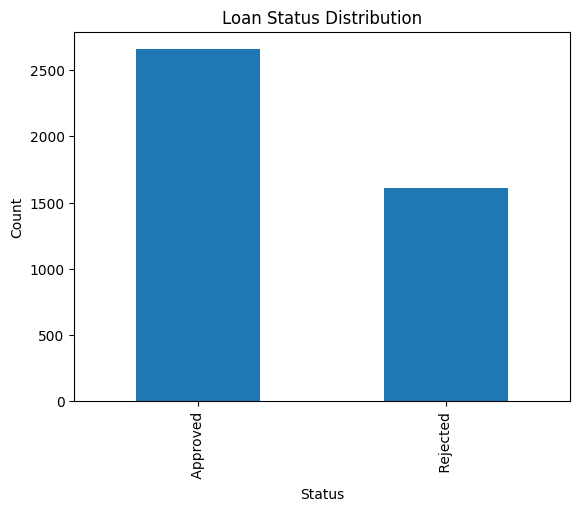

In [ ]:
df['loan_status'].value_counts().plot(kind='bar')
plt.title("Loan Status Distribution")
plt.xlabel("Status")
plt.ylabel("Count")
plt.show()

In [ ]:
le = LabelEncoder()

df['education'] = le.fit_transform(df['education'])
df['self_employed'] = le.fit_transform(df['self_employed'])
df['loan_status'] = le.fit_transform(df['loan_status'])

In [ ]:
X = df.drop('loan_status', axis=1)
y = df['loan_status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
lr_model = LogisticRegression(max_iter=1000)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

lr_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
lr_pred = lr_model.predict(X_test)
rf_pred = rf_model.predict(X_test)

In [ ]:
lr_acc = accuracy_score(y_test, lr_pred)
rf_acc = accuracy_score(y_test, rf_pred)

print("Logistic Regression:", lr_acc)
print("Random Forest:", rf_acc)

Logistic Regression: 0.8220140515222483
Random Forest: 0.9765807962529274


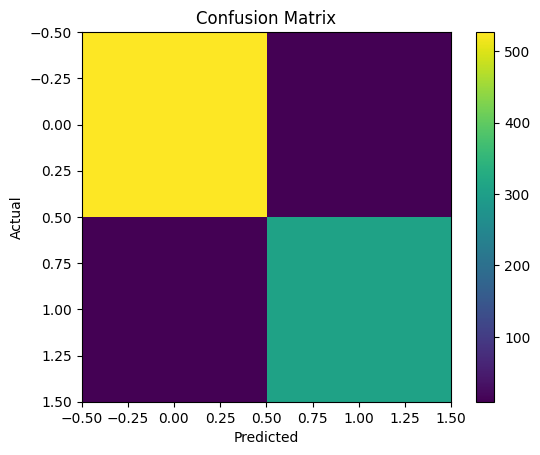

In [ ]:
cm = confusion_matrix(y_test, rf_pred)

plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

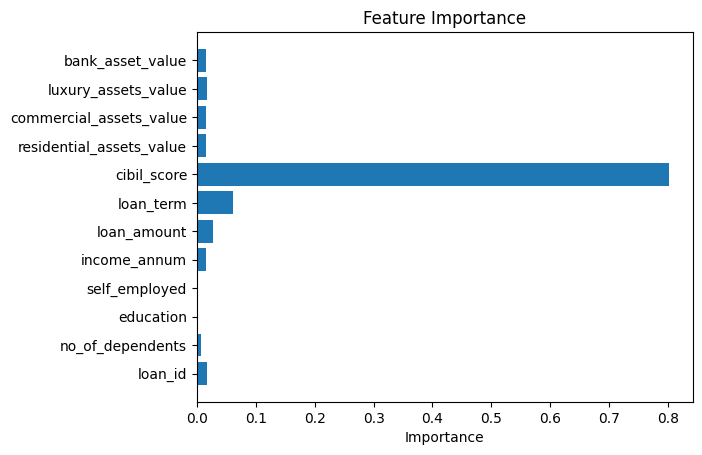

In [ ]:
importances = rf_model.feature_importances_
features = X.columns

plt.barh(features, importances)
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.show()

In [ ]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       536
           1       0.97      0.97      0.97       318

    accuracy                           0.98       854
   macro avg       0.98      0.97      0.97       854
weighted avg       0.98      0.98      0.98       854

